<a href="https://colab.research.google.com/github/appleflavorMilk/machineRunnigstudy/blob/main/linear_regression_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
# 농어 데이터 nmpy배열로 받기
perch_length = np.array(
    [8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0,
     21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5,
     22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5,
     27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0,
     36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0,
     40.0, 42.0, 43.0, 43.0, 43.5, 44.0]
     )
perch_weight = np.array(
    [5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0,
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0,
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0,
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0,
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0,
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0,
     1000.0, 1000.0]
     )

In [2]:
from sklearn.model_selection import train_test_split
#훈련 세트 와 테스트 세트로 나누기
train_input, test_input, train_target, test_target = train_test_split(perch_length,perch_weight,random_state = 42)

In [3]:
#위 상태로 나누면 1행 짜리 값으로 나뉘기 때문에 2차원 배열로 바꿔야됨. 결과를 transpose한다는 뜻.
train_input = train_input.reshape(-1,1)
test_input  = test_input.reshape(-1,1)

In [5]:
#Kneighbors를 이용하면 훈련 세트를 벗어난 값을 예측하려 할 때 오류가 나온다. 즉 다른 알고리즘이 필요!
#선형 회귀 알고리즘을 사용할 것~
#선형 회귀 알고리즘은 특성이 하나인 경우 어떤 직선을 학습하는 알고리즘
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
#선형회귀를 훈련한다./
lr.fit(train_input,train_target)
print(train_input[:5])
#50cm 농어에대해 예측합니다.
print(lr.predict([[50]]))

[[19.6]
 [22. ]
 [18.7]
 [17.4]
 [36. ]]
[1241.83860323]


In [6]:
#lr 객체에는 직선의 기울기와 절편에 속하는 계수와 가중치를 알수 있다. coef_,intercept_
print(lr.coef_,lr.intercept_)

[39.01714496] -709.0186449535477


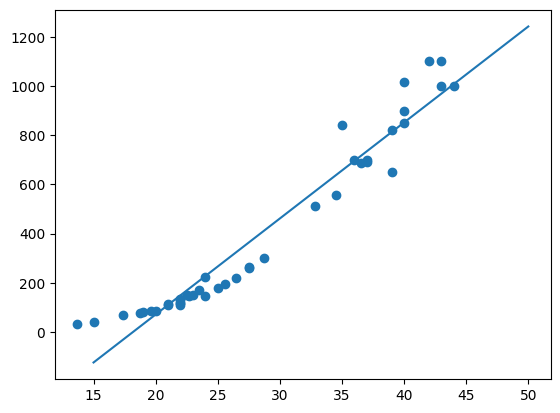

In [8]:
from matplotlib import pyplot as plt
#산점도를 그리는 용
plt.scatter(train_input,train_target)
#농어의 길이 15에서 50까지의 직선을 그려보자.1차 방정식 그리기
plt.plot([15,50],[15*lr.coef_+lr.intercept_,50*lr.coef_+lr.intercept_])

In [9]:
print(lr.score(test_input,test_target))

0.8247503123313558


In [11]:
#위와 같이 학습데이터가 안좋은 이유는 1차방정식으로 만들경우 길이가 낮아질수록 y축 값이 0아래로 넘어갈 가능성이 존재하기 때문.
#이를 방지하기 위해서 2차 방정식 형태로 만드는 것이 best.
#최적의 곡선을 만들기위해 a*길이^2 +b*길이 +c 꼴로 만들어 보기로 결정.
#이를 위해서 훈련 세트에 길이 데이터를 제곱한 행을 concate하면 된다.
train_poly = np.column_stack((train_input**2,train_input))
test_poly = np.column_stack((test_input**2,test_input))
print(train_poly.shape,test_poly.shape)

(42, 2) (14, 2)


In [12]:
lr.fit(train_poly,train_target)
print(lr.predict([[50**2,50]]))

[1573.98423528]


In [13]:
print(lr.coef_,lr.intercept_)

[  1.01433211 -21.55792498] 116.0502107827827


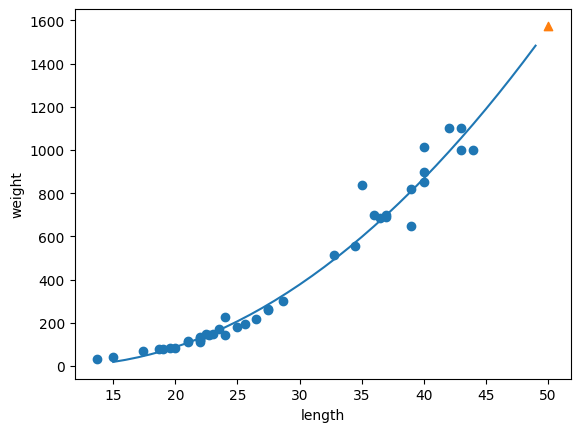

In [14]:
#위 같은 다항식을 이용한 것을 다항회귀라고 한다.
point = np.arange(15,50)
#구간별 직선을 구하기 위해서 15에서 49까지 정수 배열을 만듬
plt.scatter(train_input,train_target)
plt.plot(point,1.01*point**2-21.6*point+116.05)
#50cm 농어 데이터
plt.scatter(50,1574,marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()